In [3]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [4]:
# Global variables
df_meta = pd.read_csv("SAMPLE_INFO.txt", sep="\t")
tpm_rady_file = "TPM_rady_080"
df_SJ_background_filtered = pd.read_csv("TPM_SJ_background_filtered.csv")
tpm_rady = pd.read_csv("TPM_combined_rady_files.tsv", sep="\t")[["symbol", tpm_rady_file]].set_index("symbol")
tpm_rady_dict = tpm_rady[tpm_rady_file].to_dict()
max_cols = 4
cancer_types = ["HGG", "LGG", "MB"]
relevant_genes = ["ATRX", "BRAF", "BRCA2", "CDKN2A", "CDKN2B", "CTNNB1", "EGFR", "FGFR1", "IDH1", "KIAA1549", "MYC", "MYCN", "PDGFRA", "PIK3CA", "PIK3R1", "PTCH1", "PTEN", "SUFU", "TP53"]
hla_genes = ["HLA-A", "HLA-B", "HLA-C", "HLA-DPA1", "HLA-DPB1", "HLA-DRB1", "HLA-DQA1", "HLA-DQB1"]
antigen_genes = ["B2M", "CALR", "CANX", "ERAP1", "HSPA5", "IFI30", "NLRC5", "P4HB", "PDIA3", "PSMB10", "PSMB9", "PSME1", "PSME2", "TAP1", "TAP2", "TAPBP", "TAPBPL", "UGT1A1", "CD274", "CTLA4", "LAG3", "PDCD1", "TNFRSF4", "CXCL13"]
group_palette = {
    "LGG": "#8dd3c7",
    "HGG": "#ffffb3",
    "MB": "#bebada",
    "Cortex": "#80b1d3",
    "Cerebellum": "#80b1d3",
}

/carter/users/affm17/jupyter-cluster-env/lib64/python3.6/site-packages/IPython/core/interactiveshell.py:3072: DtypeWarning: Columns (9,10) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [5]:
df_cortex = pd.read_csv("gene_tpm_brain_cortex.gct", sep="\t")
df_cortex = df_cortex.rename(columns={df_cortex.columns[0]: "Gene_ID", df_cortex.columns[1]: "Gene"})
df_cortex = df_cortex.set_index("Gene")
df_cortex = df_cortex.drop(columns="Gene_ID")

In [6]:
df_cerebellum = pd.read_csv("gene_tpm_brain_cerebellum.gct", sep="\t")
df_cerebellum = df_cerebellum.rename(columns={df_cerebellum.columns[1]: "Gene_ID", df_cerebellum.columns[2]: "Gene"})
df_cerebellum = df_cerebellum.set_index("Gene")
df_cerebellum = df_cerebellum.drop(columns=["id", "Gene_ID"])

In [7]:
# Filter out SJ samples that are in HGG, LGG, or MB
df_meta_sj = df_meta[df_meta["sample_name"].str.startswith("SJ")]
df_meta_sj = df_meta_sj[df_meta_sj["sj_diseases"].isin(cancer_types)]
valid_sj  = df_meta_sj["subject_name"].tolist()
valid_sj = list(set(valid_sj))
# Create a clean ID mapping -> cancer type
sj_to_cancer = df_meta_sj.set_index("subject_name")["sj_diseases"].to_dict()

In [8]:
columns = df_SJ_background_filtered.columns
for cancer in cancer_types:
    sj_ids = [sj for sj in columns if sj_to_cancer.get(sj) == cancer]
    print(f"{cancer}: {len(sj_ids)} samples")

HGG: 111 samples
LGG: 125 samples
MB: 98 samples


In [11]:
# Functions

def data_long_func(genes, df):
    data_long = []
    for gene in genes:
        for sample in df.columns:
            if sample in sj_to_cancer:
                group = sj_to_cancer[sample]
                tpm = df.loc[gene, sample]
                data_long.append({
                    "Gene": gene,
                    "TPM": tpm,
                    "logTPM": np.log(tpm + 1),
                    "Group": group
                })
    df_long_tumor = pd.DataFrame(data_long)
    return df_long_tumor

def melt_brain_df(df, label, genes):
    df_ = df[df.index.isin(genes)].copy()
    df_["Gene"] = df_.index
    df_ = df_.reset_index(drop=True)
    df_long = df_.melt(id_vars="Gene", var_name="Sample", value_name="TPM")
    df_long["logTPM"] = np.log(df_long["TPM"] + 1)
    df_long["Group"] = label
    return df_long

def plot_grouped_boxplots(ax, df, genes, groups, palette, title, tpm_rady=None):
    x_max = df["logTPM"].max() + 1
    
    for i, gene in enumerate(genes):
        for j, group in enumerate(groups):
            subset = df[(df["Gene"] == gene) & (df["Group"] == group)]
            y_pos = i + j * 0.25 - (0.25 * (len(groups) - 1) / 2)
            ax.boxplot(
                subset["logTPM"], vert=False, positions=[y_pos], widths=0.2,
                patch_artist=True,
                boxprops=dict(facecolor=palette[group], color="black"),
                medianprops=dict(color="black"),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
                flierprops=dict(marker='o', markersize=3, linestyle='none', markerfacecolor=palette[group])
            )
            
            if tpm_rady is not None and gene in tpm_rady:
                val = tpm_rady[gene]
                x_val = np.log(val + 1)

                mean = subset["logTPM"].mean()
                std = subset["logTPM"].std()

                if len(subset) > 1 and std != 0:
                    z = (x_val - mean) / std
                    ax.plot([x_val, x_val], [y_pos - 0.08, y_pos + 0.08], color="red", linewidth=1.8, zorder=5)
                    ax.text(x_max, y_pos, f"z={z:.2f}", color="red", fontsize=8, va='center', ha='left')
            
    ax.set_yticks(range(len(genes)))
    ax.set_yticklabels(genes)
    ax.set_title(title)
    ax.set_xlabel("log(TPM + 1)")
    ax.set_ylabel("Gene")

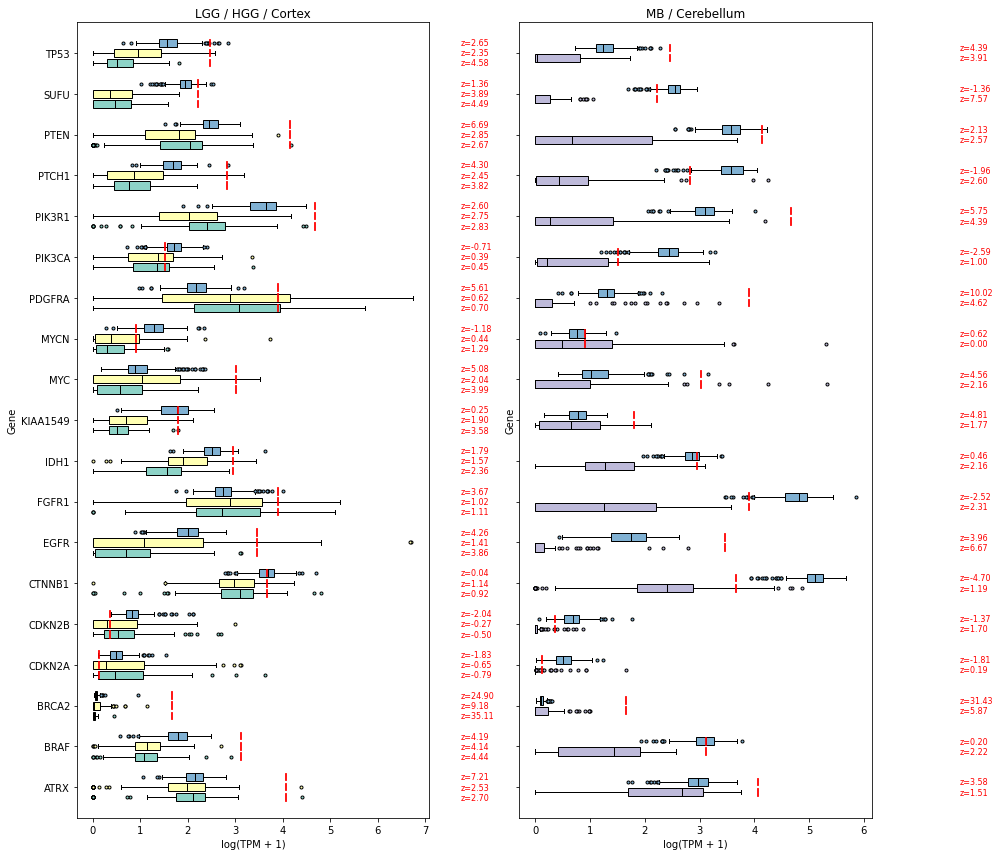

Total Z-score for LGG: 77.61
Total Z-score for HGG: 39.72
Total Z-score for Cortex: 68.84
Total Z-score for MB: 54.41
Total Z-score for Cerebellum: 55.60


In [16]:
# Filter by relevant genes
df_long_cortex = melt_brain_df(df_cortex, "Cortex", relevant_genes)
df_long_cerebellum = melt_brain_df(df_cerebellum, "Cerebellum", relevant_genes)
df_long_normal = pd.concat([df_long_cortex, df_long_cerebellum], ignore_index=True)

df_relevant_genes = df_SJ_background_filtered[df_SJ_background_filtered["Gene"].isin(relevant_genes)]
df_relevant_genes.set_index("Gene", inplace=True)
df_long_tumor = data_long_func(relevant_genes, df_relevant_genes)
fig, axes = plt.subplots(1, 2, figsize=(14, 12), sharey=True)

# Column 1: LGG / HGG / Cortex
plot_grouped_boxplots(
    axes[0],
    pd.concat([df_long_tumor, df_long_normal], ignore_index=True),
    relevant_genes,
    ["LGG", "HGG", "Cortex"],
    group_palette,
    "LGG / HGG / Cortex",
    tpm_rady=tpm_rady_dict
)

# Column 2: MB / Cerebellum
plot_grouped_boxplots(
    axes[1],
    pd.concat([df_long_tumor, df_long_normal], ignore_index=True),
    relevant_genes,
    ["MB", "Cerebellum"],
    group_palette,
    "MB / Cerebellum",
    tpm_rady=tpm_rady_dict
)

plt.tight_layout()
plt.show()

from collections import defaultdict
import numpy as np

df_all = pd.concat([df_long_tumor, df_long_normal], ignore_index=True)

zscore_totals = defaultdict(float)

for group in ["LGG", "HGG", "Cortex", "MB", "Cerebellum"]:
    for gene in relevant_genes:
        subset = df_all[(df_all["Gene"] == gene) & (df_all["Group"] == group)]
        if gene in tpm_rady_dict:
            tpm_rady = tpm_rady_dict[gene]
            log_val = np.log(tpm_rady + 1)
            mean = subset["logTPM"].mean()
            std = subset["logTPM"].std()
            if len(subset) > 1 and std != 0:
                z = (log_val - mean) / std
                zscore_totals[group] += z

for group, total in zscore_totals.items():
    print(f"Total Z-score for {group}: {total:.2f}")

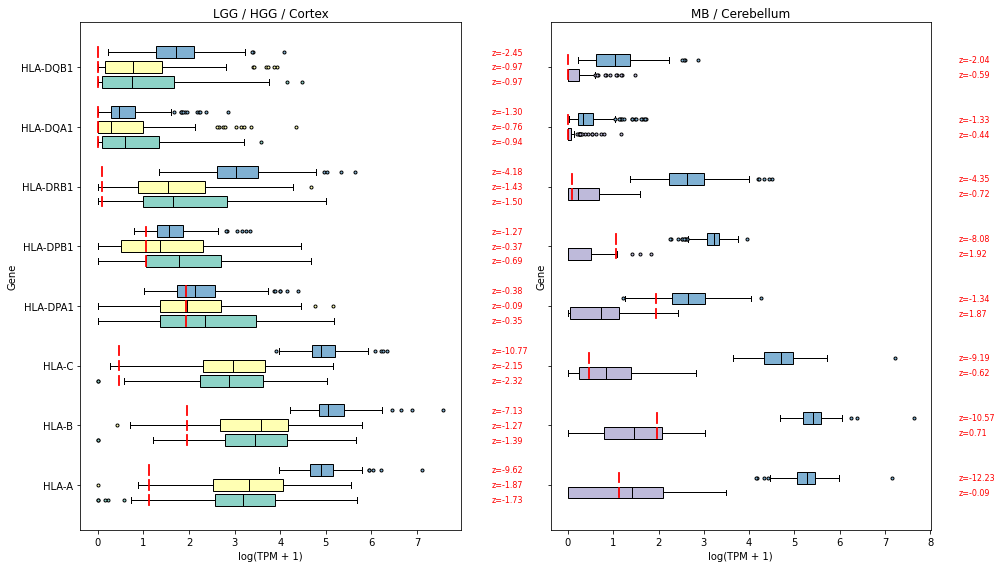

Total Z-score for LGG: -9.88
Total Z-score for HGG: -8.92
Total Z-score for Cortex: -37.09
Total Z-score for MB: 2.04
Total Z-score for Cerebellum: -49.13


In [19]:
# Filter by HLA
df_long_cortex = melt_brain_df(df_cortex, "Cortex", hla_genes)
df_long_cerebellum = melt_brain_df(df_cerebellum, "Cerebellum", hla_genes)
df_long_normal = pd.concat([df_long_cortex, df_long_cerebellum], ignore_index=True)

df_hla_genes = df_SJ_background_filtered[df_SJ_background_filtered["Gene"].isin(hla_genes)]
df_hla_genes.set_index("Gene", inplace=True)
df_long_tumor = data_long_func(hla_genes, df_hla_genes)
fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)

# Column 1: LGG / HGG / Cortex
plot_grouped_boxplots(
    axes[0],
    pd.concat([df_long_tumor, df_long_normal], ignore_index=True),
    hla_genes,
    ["LGG", "HGG", "Cortex"],
    group_palette,
    "LGG / HGG / Cortex",
    tpm_rady=tpm_rady_dict
)

# Column 2: MB / Cerebellum
plot_grouped_boxplots(
    axes[1],
    pd.concat([df_long_tumor, df_long_normal], ignore_index=True),
    hla_genes,
    ["MB", "Cerebellum"],
    group_palette,
    "MB / Cerebellum",
    tpm_rady=tpm_rady_dict
)

plt.tight_layout()
plt.show()

from collections import defaultdict
import numpy as np

df_all = pd.concat([df_long_tumor, df_long_normal], ignore_index=True)

zscore_totals = defaultdict(float)

for group in ["LGG", "HGG", "Cortex", "MB", "Cerebellum"]:
    for gene in hla_genes:
        subset = df_all[(df_all["Gene"] == gene) & (df_all["Group"] == group)]
        if gene in tpm_rady_dict:
            tpm_rady = tpm_rady_dict[gene]
            log_val = np.log(tpm_rady + 1)
            mean = subset["logTPM"].mean()
            std = subset["logTPM"].std()
            if len(subset) > 1 and std != 0:
                z = (log_val - mean) / std
                zscore_totals[group] += z

for group, total in zscore_totals.items():
    print(f"Total Z-score for {group}: {total:.2f}")

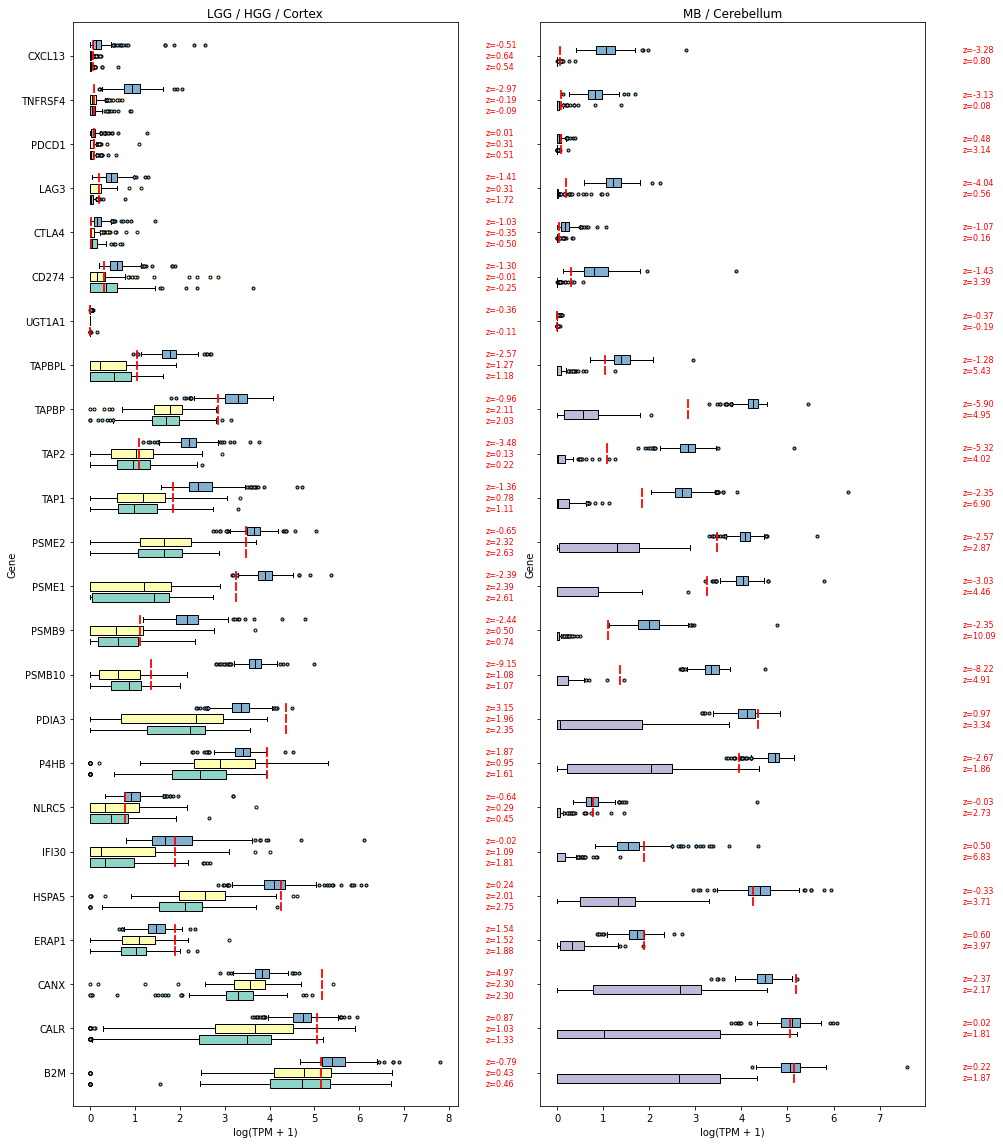

Total Z-score for LGG: 28.35
Total Z-score for HGG: 22.85
Total Z-score for Cortex: -19.38
Total Z-score for MB: 79.86
Total Z-score for Cerebellum: -42.22


In [20]:
# Filter by Antigen
df_long_cortex = melt_brain_df(df_cortex, "Cortex", antigen_genes)
df_long_cerebellum = melt_brain_df(df_cerebellum, "Cerebellum", antigen_genes)
df_long_normal = pd.concat([df_long_cortex, df_long_cerebellum], ignore_index=True)

df_antigen_genes = df_SJ_background_filtered[df_SJ_background_filtered["Gene"].isin(antigen_genes)]
df_antigen_genes.set_index("Gene", inplace=True)
df_long_tumor = data_long_func(antigen_genes, df_antigen_genes)
fig, axes = plt.subplots(1, 2, figsize=(14, 16), sharey=True)

# Column 1: LGG / HGG / Cortex
plot_grouped_boxplots(
    axes[0],
    pd.concat([df_long_tumor, df_long_normal], ignore_index=True),
    antigen_genes,
    ["LGG", "HGG", "Cortex"],
    group_palette,
    "LGG / HGG / Cortex",
    tpm_rady=tpm_rady_dict
)

# Column 2: MB / Cerebellum
plot_grouped_boxplots(
    axes[1],
    pd.concat([df_long_tumor, df_long_normal], ignore_index=True),
    antigen_genes,
    ["MB", "Cerebellum"],
    group_palette,
    "MB / Cerebellum",
    tpm_rady=tpm_rady_dict
)

plt.tight_layout()
plt.show()

from collections import defaultdict
import numpy as np

df_all = pd.concat([df_long_tumor, df_long_normal], ignore_index=True)

zscore_totals = defaultdict(float)

for group in ["LGG", "HGG", "Cortex", "MB", "Cerebellum"]:
    for gene in antigen_genes:
        subset = df_all[(df_all["Gene"] == gene) & (df_all["Group"] == group)]
        if gene in tpm_rady_dict:
            tpm_rady = tpm_rady_dict[gene]
            log_val = np.log(tpm_rady + 1)
            mean = subset["logTPM"].mean()
            std = subset["logTPM"].std()
            if len(subset) > 1 and std != 0:
                z = (log_val - mean) / std
                zscore_totals[group] += z

for group, total in zscore_totals.items():
    print(f"Total Z-score for {group}: {total:.2f}")